In [1]:
!pip install lightgbm[gpu]

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
import lightgbm as lgb
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score

import shap
import lime

import joblib

In [3]:
def plot_confusion_matrix(y_true, y_pred, model_name="Model", figsize=(8, 6)):
    """
    Create a nice confusion matrix visualization for any model
    
    Parameters:
    y_true: actual labels
    y_pred: predicted labels  
    model_name: name of the model for the title
    figsize: figure size tuple
    """
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=figsize)
    plt.imshow(cm, interpolation='nearest', cmap='Blues')
    plt.title(f'{model_name} - Confusion Matrix', fontsize=16, fontweight='bold')
    plt.colorbar()
    
    # Add text annotations
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], 'd'),
                    horizontalalignment="center",
                    color="white" if cm[i, j] > thresh else "black",
                    fontsize=14, fontweight='bold')
    
    # Add labels
    plt.ylabel('True Label', fontsize=12, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
    plt.xticks([0, 1], ['No Heart Disease', 'Heart Disease'])
    plt.yticks([0, 1], ['No Heart Disease', 'Heart Disease'])
    
    # Calculate and display accuracy
    accuracy = (cm[0,0] + cm[1,1]) / cm.sum()
    plt.suptitle(f'Accuracy: {accuracy:.3f}', fontsize=14, y=0.02)
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed metrics
    print(f"\n{model_name} Performance:")
    print(f"True Negatives: {cm[0,0]}")
    print(f"False Positives: {cm[0,1]}")
    print(f"False Negatives: {cm[1,0]}")
    print(f"True Positives: {cm[1,1]}")
    print(f"Accuracy: {accuracy:.3f}")
    
    # Calculate additional metrics
    precision = cm[1,1] / (cm[1,1] + cm[0,1]) if (cm[1,1] + cm[0,1]) > 0 else 0
    recall = cm[1,1] / (cm[1,1] + cm[1,0]) if (cm[1,1] + cm[1,0]) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    print(f"Precision: {precision:.3f}")
    print(f"Recall: {recall:.3f}")
    print(f"F1-Score: {f1:.3f}")
    
    return cm, accuracy

In [4]:
def plot_roc_curve(y_true, y_pred_proba, model_name="Model", figsize=(8, 6)):
    """
    Create a nice ROC curve visualization for any model
    
    Parameters:
    y_true: actual labels
    y_pred_proba: predicted probabilities (for positive class)
    model_name: name of the model for the title
    figsize: figure size tuple
    """
    # Calculate ROC curve
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
    auc_score = roc_auc_score(y_true, y_pred_proba)
    
    plt.figure(figsize=figsize)
    
    # Plot ROC curve
    plt.plot(fpr, tpr, color='darkorange', lw=2, 
             label=f'{model_name} (AUC = {auc_score:.3f})')
    
    # Plot diagonal line (random classifier)
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', 
             label='Random Classifier (AUC = 0.500)')
    
    # Formatting
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
    plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
    plt.title(f'{model_name} - ROC Curve', fontsize=16, fontweight='bold')
    plt.legend(loc="lower right", fontsize=10)
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print AUC score
    print(f"\n{model_name} ROC AUC Score: {auc_score:.3f}")
    
    # Interpretation
    if auc_score > 0.9:
        print("Excellent performance!")
    elif auc_score > 0.8:
        print("Good performance!")
    elif auc_score > 0.7:
        print("Fair performance")
    elif auc_score > 0.6:
        print("Poor performance")
    else:
        print("Very poor performance")
    
    return fpr, tpr, auc_score

In [5]:
data = pd.read_csv('/kaggle/input/heart-prediction-preprocessed/heart_preprocessed_scaled.csv')

In [6]:
X = data.drop('HeartDisease', axis=1)
y = data['HeartDisease']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [7]:
params = {
    'n_estimators': [100, 200, 500],
    'learning_rate': [0.01, 0.1],
    'max_depth': [-1, 10],
    'num_leaves': [31, 63],
    'min_child_samples': [20, 50],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8],  # Fixed to 0.8 (good default)
    'reg_alpha': [0, 0.1],
    'reg_lambda': [0],  # Fixed to 0 (use only L1 or neither)
    'class_weight': [None, 'balanced'],
    'device': ['gpu'],
    'random_state': [42],
    'verbose': [-1]
}


grid_lgb = GridSearchCV(lgb.LGBMClassifier(), param_grid=params, cv=5, scoring='f1', verbose=1)
grid_lgb.fit(X_train, y_train)

Fitting 5 folds for each of 384 candidates, totalling 1920 fits


1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


GridSearchCV(cv=5, estimator=LGBMClassifier(),
             param_grid={'class_weight': [None, 'balanced'],
                         'colsample_bytree': [0.8], 'device': ['gpu'],
                         'learning_rate': [0.01, 0.1], 'max_depth': [-1, 10],
                         'min_child_samples': [20, 50],
                         'n_estimators': [100, 200, 500],
                         'num_leaves': [31, 63], 'random_state': [42],
                         'reg_alpha': [0, 0.1], 'reg_lambda': [0],
                         'subsample': [0.8, 1.0], 'verbose': [-1]},
             scoring='f1', verbose=1)

In [8]:
print(f"Best parameters: {grid_lgb.best_params_}")
print(f"Best cross-validation score: {grid_lgb.best_score_}")

Best parameters: {'class_weight': None, 'colsample_bytree': 0.8, 'device': 'gpu', 'learning_rate': 0.01, 'max_depth': -1, 'min_child_samples': 20, 'n_estimators': 500, 'num_leaves': 31, 'random_state': 42, 'reg_alpha': 0, 'reg_lambda': 0, 'subsample': 0.8, 'verbose': -1}
Best cross-validation score: 0.8754062765844377


In [9]:
lgb_pred = grid_lgb.predict(X_test)

In [10]:
print(classification_report(y_test, lgb_pred))

              precision    recall  f1-score   support

           0       0.84      0.88      0.86        82
           1       0.90      0.86      0.88       102

    accuracy                           0.87       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.87      0.87      0.87       184



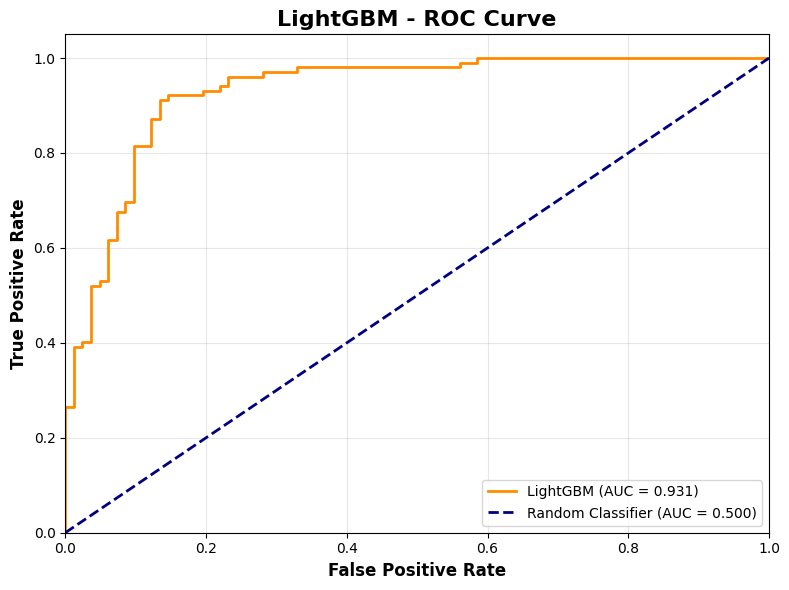


LightGBM ROC AUC Score: 0.931
Excellent performance!


In [11]:
lgb_proba = grid_lgb.predict_proba(X_test)[:, 1]
lgb_fpr, lgb_tpr, lgb_thresholds = plot_roc_curve(y_test, lgb_proba, 'LightGBM')

LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray


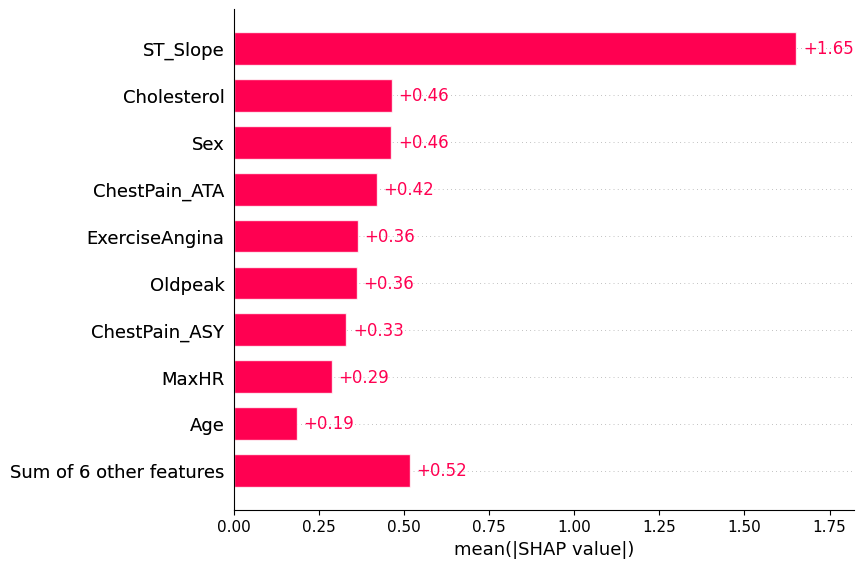

In [12]:
explainer = shap.TreeExplainer(grid_lgb.best_estimator_)
shap_values = explainer.shap_values(X_test)

# shap_values from KernelExplainer can be a list (one array per class) or a 3D numpy array
# with shape (n_samples, n_features, n_classes). Select the positive class (index 1)
# and wrap into a shap.Explanation so shap.plots.bar accepts it.
class_idx = 1

if isinstance(shap_values, list):
	values = shap_values[class_idx]
elif hasattr(shap_values, "shape") and len(shap_values.shape) == 3:
	values = shap_values[..., class_idx]
else:
	# fallback: assume shap_values already in the desired 2D shape
	values = shap_values

base_values = explainer.expected_value[class_idx] if hasattr(explainer.expected_value, "__len__") else explainer.expected_value

shap_exp = shap.Explanation(values=values, base_values=base_values, data=X_test, feature_names=X_test.columns)
shap.plots.bar(shap_exp)

In [ ]:
lime_explainer = lime.lime_tabular.LimeTabularExplainer(training_data=X_train.values, feature_names=X_train.columns, class_names=['No Heart Disease', 'Heart Disease'], mode='classification')
i = 180
exp = lime_explainer.explain_instance(data_row=X_test.values[i], predict_fn=grid_lgb.predict_proba)
exp.show_in_notebook(show_table=True)

In [ ]:
joblib.dump(grid_lgb, '/kaggle/working/lightgbm_model.pkl')

['/kaggle/working/lightgbm_model.pkl']